In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pickle
import re
                                                             

In [2]:
DROP_IRRELEVANT = True
LABEL_COL = "label"

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text


In [3]:
if DROP_IRRELEVANT:
    before = len(df)
    df = df[df[LABEL_COL] != "irrelevant"].reset_index(drop=True)
    print(f"Dropped 'irrelevant': {before - len(df)} rows removed")


NameError: name 'df' is not defined

In [ ]:
# Load data
df = pd.read_csv('twitter_training.csv', header=None, names=['post_id', 'topic', 'label', 'text', 'text_clean'])
# Use text for training
X = df['text'].fillna('').apply(clean_text)
y = df['label']
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', RandomForestClassifier(random_state=42))
])
# Train
pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [ ]:
# Evaluate
y_pred = pipeline.predict(X_test)
print("here is perfomrmance metric:")
print(classification_report(y_test, y_pred))

here is perfomrmance metric:
              precision    recall  f1-score   support

  Irrelevant       0.96      0.78      0.86      2598
    Negative       0.88      0.90      0.89      4509
     Neutral       0.83      0.89      0.86      3664
    Positive       0.87      0.89      0.88      4166

    accuracy                           0.87     14937
   macro avg       0.88      0.86      0.87     14937
weighted avg       0.88      0.87      0.87     14937



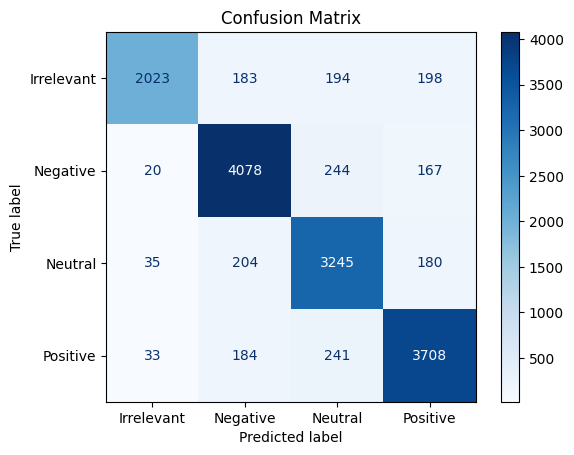

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import pandas as pd

# compute confusion matrix FIRST
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(y_test)
)

disp.plot(cmap="Blues", values_format="d", colorbar=True)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Save model
with open('SentimentAnalysis.pickle', 'wb') as f:
    pickle.dump(pipeline, f)
examples = [
    "I love this phone!",
    "This is the worst movie ever.",
    "It’s okay, not great but not bad either."
]
print(pipeline.predict(examples))

print("Model retrained and saved.")

['Positive' 'Negative' 'Positive']
Model retrained and saved.
